In [69]:
from micrograd.engine import Value



In [70]:
a = Value(-4.0)
b = Value(2.0)
c = a+b
d = a*b + b**3
c+= c+1
c+=1+c+(-a)
d+=d*2+(b+a).relu()
d+=3*d+(b-a).relu()
e=c-d
f=e**2
g=f/2.0
g+=10.0/f
print(f'{g.data:.4f}')
g.backward()
print(f'{a.grad:.4f}')
print(f'{b.grad:.4f}')

24.7041
138.8338
645.5773


In [71]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


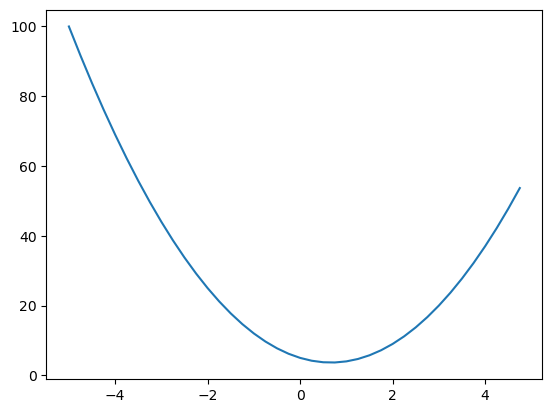

In [72]:
def f(x):
    return 3*x**2-4*x+5

f(3.0)
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys)
plt.show()

In [73]:
a = 2.0
b = -3.0
c = 10
d = a*b+c
print(d)
h = 0.000001
d1 = a*b+c
a+=h
d2 = a*b+c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)


4.0
d1 4.0
d2 3.9999969999999996
slope -3.000000000419334


In [74]:
class Value:
    def __init__(self, data, _childern= (), _op='', label=''):
        self.data = data
        self._prev = set(_childern)
        self._op = _op
        self._backward = lambda:None
        self.label = label
        self.grad = 0.0
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data+other.data, (self,other),'+')
        def _backward():
            self.grad += 1.0*out.grad
            other.grad += 1.0*out.grad
        out._backward = _backward
        return out
    def __mul__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data*other.data, (self,other),'*')
        def _backward():
            self.grad += other.data*out.grad
            other.grad += self.data*out.grad
        out._backward = _backward
        return out
    def __pow__(self,other):
        assert isinstance(other,(int,float)), "only for int/float"
        out = Value(self.data**other, (self,),f'**{other}')
        def _backward():
            self.grad+= other*(self.data**(other-1))*out.grad
        out._backward = _backward
        return out
    def __rmul__(self, other):
        return self*other
    def __truediv__(self,other):
        return self*other**-1
    def __rtruediv__(self,other):
        return self*other**-1
    def __neg__(self):
        return self*-1
    def __sub__(self,other):
        return self+(-other)
    def __radd__(self,other):
        return self+other
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t,(self,), 'tanh')
        def _backward():
            self.grad += (1-t**2)*out.grad

        out._backward = _backward
        return out
    def exp(self):
        x = self.data
        out = Value(math.exp(x),(self, ), 'exp')
        def _backward():
            self.grad += out.data*out.grad
        out._backward = _backward
        return out
    def backward(self):
        self.grad = 1.0
        topo = []
        visited = set()
        def BuildTopoSort(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    BuildTopoSort(child)
                topo.append(v)
        BuildTopoSort(self)
        for i in range(len(topo)-1,-1,-1):
            topo[i]._backward()


a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
f = Value(-2.0, label = 'f')
print(a*b+c)
e = a*b; e.label = 'e'
d = e+c; d.label = 'd'
L = d*f; L.label = 'L'
L

Value(data=4.0)


Value(data=-8.0)

In [75]:


from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot
f.grad=4.0
c.grad = -2.0
e.grad = -2.0
a.grad = 6.0
b.grad = -4.0


In [76]:
L.grad=1.0
d.grad = -2.0

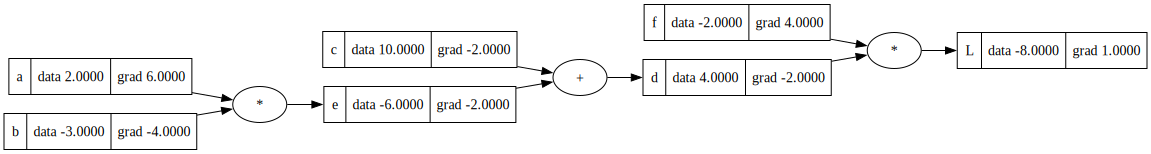

In [77]:
draw_dot(L)

In [78]:
a.data+=0.01*a.grad
b.data+=0.01*b.grad
c.data+=0.01*c.grad
f.data+=0.01*f.grad

e = a * b 
d = e + c
L = d * f

print(L.data)


-7.286496


In [79]:
def lol():
    h = 0.001
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    a.data+=h
    e = a*b; e.label = 'e'
    d = e+c; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d*f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e+c; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d*f; L.label = 'L'
    L2 = L.data
    

    print((L2-L1)/h)

lol()

-6.000000000000227


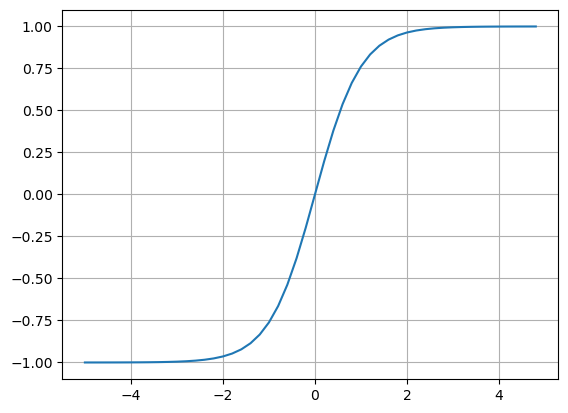

In [80]:
plt.plot(np.arange(-5,5,.2),np.tanh(np.arange(-5,5,.2)));plt.grid()
plt.show()

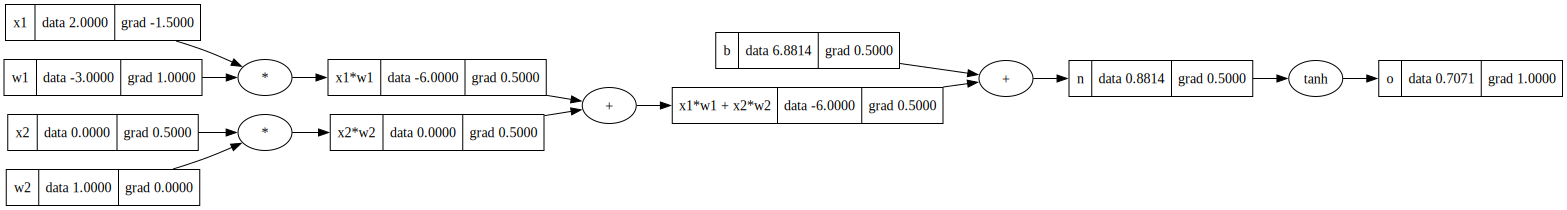

In [81]:

# input
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
#weights
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
#bias
b = Value(6.881375870195432, label = 'b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2+b; n.label = 'n'
o = n.tanh();o.label = 'o'
o.backward()
draw_dot(o)


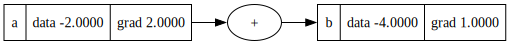

In [82]:
a = Value(-2.0, label = 'a')
b = a+a; b.label = 'b'
b.backward()
draw_dot(b)

In [83]:
a = Value(2.0)
b = Value(4.0)


In [84]:
a-b
a/b
a*(1/b)


Value(data=8.0)

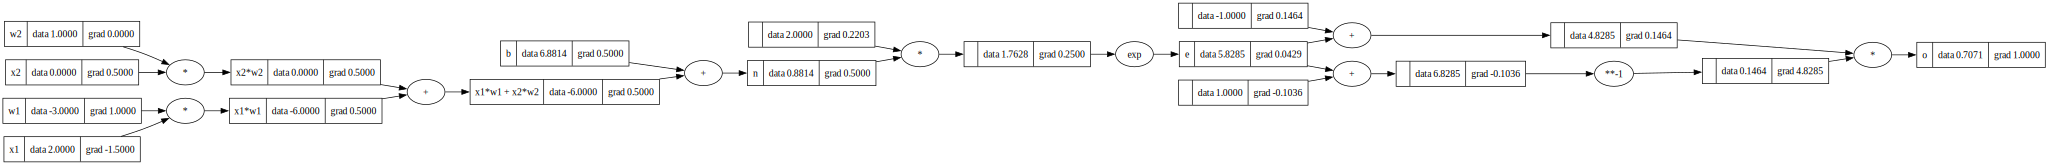

In [85]:

# input
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
#weights
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
#bias

b = Value(6.881375870195432, label = 'b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2+b; n.label = 'n'
e = (2*n).exp(); e.label = 'e'
o = (e-1)/(e+1);o.label = 'o'
o.backward()
draw_dot(o)

In [86]:
import torch
import random
x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('___')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

torch.Tensor([2.0]).double().dtype



class Neuron: 
    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self,x):
        act = sum((wi*xi for wi,xi in zip(self.w, x)),self.b)
        out = act.tanh()
        return out
    def parameters(self):
        return self.w + [self.b]
class Layer:
    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
class MLP:
    def __init__(self,nin,nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
        

x = [2.0,3.0, -1.0]
n = MLP(3,[4,4,1])


0.7071066904050358
___
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


0 Value(data=5.018239658086834)
1 Value(data=5.016465199755904)
2 Value(data=5.014691070299737)
3 Value(data=5.0129172736369)
4 Value(data=5.011143813686136)
5 Value(data=5.009370694366318)
6 Value(data=5.00759791959641)
7 Value(data=5.005825493295422)
8 Value(data=5.004053419382371)
9 Value(data=5.002281701776225)
10 Value(data=5.000510344395879)
11 Value(data=4.998739351160097)
12 Value(data=4.996968725987482)
13 Value(data=4.995198472796416)
14 Value(data=4.993428595505032)
15 Value(data=4.991659098031163)
16 Value(data=4.989889984292303)
17 Value(data=4.988121258205558)
18 Value(data=4.98635292368761)
19 Value(data=4.984584984654669)
[Value(data=-0.49263298894501556), Value(data=-0.604199508491089), Value(data=-0.5617797915953464), Value(data=-0.551752804036398)]


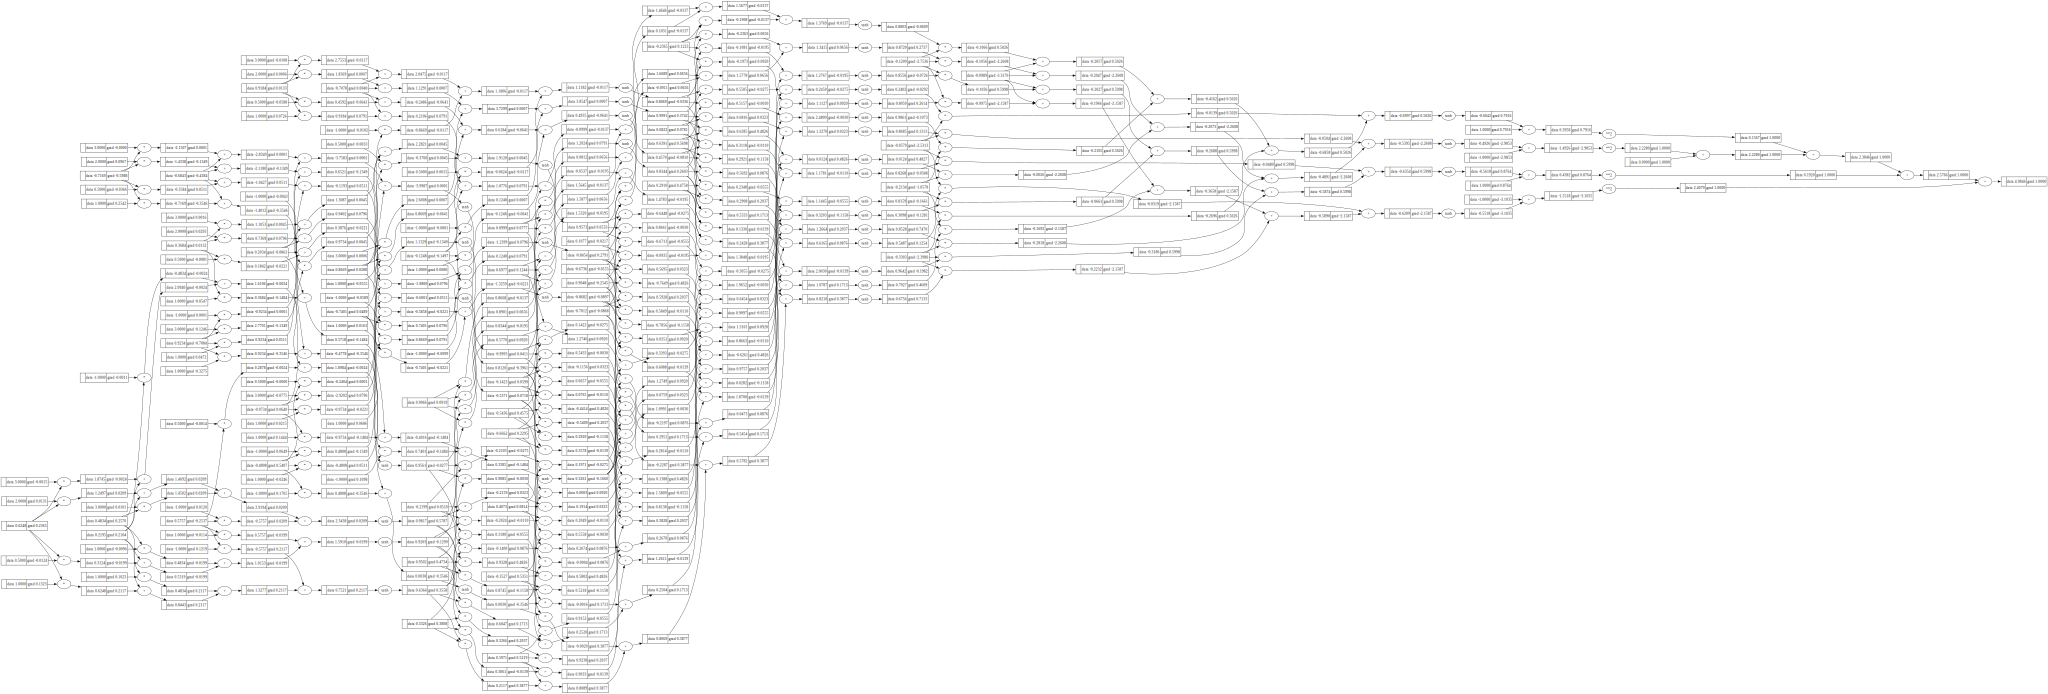

In [87]:
xs = [
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0],
]

ys = [1.0,-1.0,-1.0,1.0]
for i in range(20):

    ypred = [n(x) for x in xs]

    loss = sum((yout-ygt)**2 for ygt, yout in zip(ys, ypred))
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()


    for p in n.parameters():
        p.data += -.00005*p.grad

    print(i, loss)
print(ypred)
draw_dot(loss)


In [88]:
print(len(n.parameters()))

41
